**This notebook is the source of all simulations for the associated presentation (and more)**

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import scipy.stats as stat

In [ ]:
import scipy.integrate as integrate

**Target functions for regression**

In [ ]:
def linear(x,a=2,b=-1):
  return a*x+b
def linear_prime(x,a=2):
  return a
def linear_seconde(x,a=2):
  return 0


def quadratic(x,a=2,b=-1,c=3):
  return a*x**2+b*x+c
def quadratic_prime(x,a=2,b=-1):
  return 2*a*x+b
def quadratic_seconde(x,a=2):
  return 2*a


def non_pol_1(x):
  return 2*x**2*np.cos(8*x)
def non_pol_1_prime(x):
  return 4*x*np.cos(8*x)-16*x**2*np.sin(8*x)
def non_pol_1_seconde(x):
  return (4-128*x**2)*np.cos(8*x)-64*x*np.sin(x)

def non_pol_2(x):
  return 2*np.exp(-2*x)*np.sin(8*x)

In [ ]:
def rectangular(x):
  if -1<=x and x<=1:
    return 1/2
  else:
    return 0
    
def triangle(x):
  if -1<=x and x<=1:
    return 1-np.abs(x )
  else:
    return 0

def epanechnikov(x):
  if -1<=x and x<=1:
    return 3/4*(1-x**2)
  else:
    return 0

def quartic(x):
  if -1<=x and x<=1:
    return 15/16*(1-x**2)**2
  else:
    return 0

def triweight(x):
  if -1<=x and x<=1:
    return (35/32)*(1-x**2)**3
  else:
    return 0

def gaussian(x): ###Non compact support
  return 1/np.sqrt(2*np.pi)*np.exp(-1/2*x**2)

In [ ]:
sigma=0.5
h=0.5

In [ ]:
def weighted_average(Y,W):
  """ W should be positive>=0 and W!=0"""
  if np.sum(W)==0:
    return np.mean(Y)
  else:
    return Y.T.dot(W)/np.sum(W)

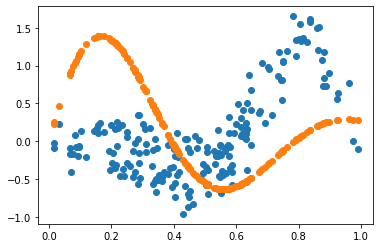

In [ ]:

def random_sample_normal(mean=1/2,var=1/4,N=100):
  '''model a prior,also returns the pdf function and its derivative'''
 
  sample=[np.random.normal(mean,var) for i in range(N)]
  sample=[s for s in sample if 0<=s and s<=1]
  sigma=np.sqrt(var)
  def pdf(x):
    if x<0 or x>1:
      return 0
    else:
      prob_accepted=stat.norm.cdf(1,mean,sigma)-stat.norm.cdf(0,mean,sigma)
      return stat.norm.pdf(x,mean,sigma)/prob_accepted ###Do not forget to renormalize because we rejected value outside [0,1]

  def pdf_prime(x):
    if x<0 or x>1:
      return 0
    else:
      return -(x-mean)/var*pdf(x)
  return np.array(sample),pdf,pdf_prime

var_noise=lambda x : sigma**2

def noise(X,func_var=var_noise): ###We can play with the noise function (as long as it has zero expected value) 
  noise=np.random.normal(0*X,func_var(X))
  return noise

X,pdf,pdf_prime=random_sample_normal(N=200)



#plt.scatter(X,Y)
#plt.show()

#X=np.linspace(0,1,200)
Y=non_pol_1(X)
Y+=noise(X)
Y2=non_pol_2(X)

plt.scatter(X,Y)
plt.scatter(X,Y2)
plt.show()

**Standard Nadaraya-Watson estimator**

In [ ]:
def weights_NW(x,X,kernel=epanechnikov,bandwidth=h):
  reduced=(x-X)/bandwidth
  W=np.array([kernel(reduced[i])/bandwidth for i in range(X.size)])  ##Here dividing by the bandwidth has no impact....but for other estimators it may
  return W

def NW(x,X,Y,kernel=epanechnikov,bandwidth=h):
  W=weights_NW(x,X,kernel=kernel,bandwidth=bandwidth)
  return weighted_average(Y,W)


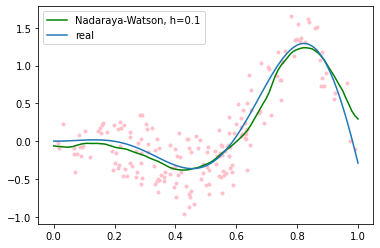

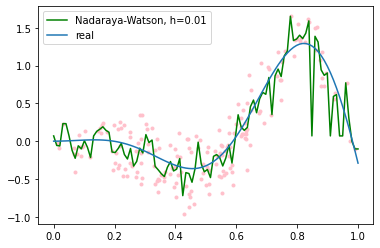

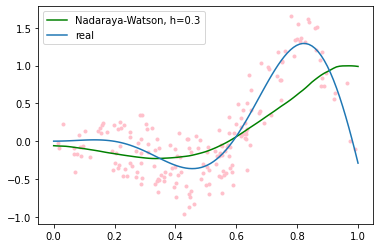

In [ ]:
#Nadaraya-Watson : how to choose bandwidth h
Xlin=np.linspace(0,1,100)

Y_hat=np.array([NW(Xlin[i],X,Y, bandwidth=0.1) for i in range(100)])
plt.scatter(X,Y,marker='.',color='pink')
plt.plot(Xlin,Y_hat,color='green',label='Nadaraya-Watson, h=0.1')
plt.plot(Xlin,non_pol_1(Xlin),label='real')
plt.legend()
plt.show()

Y_hat=np.array([NW(Xlin[i],X,Y, bandwidth=0.01) for i in range(100)])
plt.scatter(X,Y,marker='.',color='pink')
plt.plot(Xlin,Y_hat,color='green',label='Nadaraya-Watson, h=0.01')
plt.plot(Xlin,non_pol_1(Xlin),label='real')
plt.legend()
plt.show()

Y_hat=np.array([NW(Xlin[i],X,Y, bandwidth=0.3) for i in range(100)])
plt.scatter(X,Y,marker='.',color='pink')
plt.plot(Xlin,Y_hat,color='green',label='Nadaraya-Watson, h=0.3')
plt.plot(Xlin,non_pol_1(Xlin),label='real')
plt.legend()
plt.show()

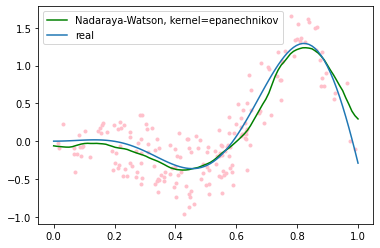

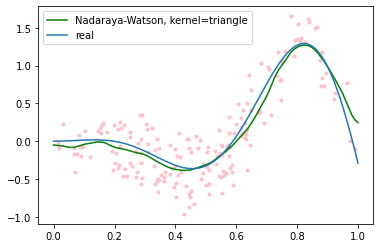

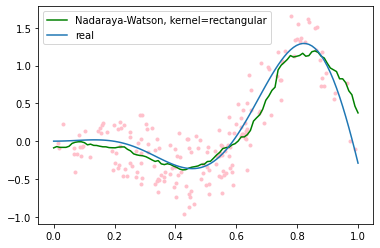

In [ ]:
#Nadaraya-Watson : choice of kernel
Xlin=np.linspace(0,1,100)

Y_hat=np.array([NW(Xlin[i],X,Y, bandwidth=0.1) for i in range(100)])
plt.scatter(X,Y,marker='.',color='pink')
plt.plot(Xlin,Y_hat,color='green',label='Nadaraya-Watson, kernel=epanechnikov')
plt.plot(Xlin,non_pol_1(Xlin),label='real')
plt.legend()
plt.show()

Y_hat=np.array([NW(Xlin[i],X,Y, kernel=triangle, bandwidth=0.1) for i in range(100)])
plt.scatter(X,Y,marker='.',color='pink')
plt.plot(Xlin,Y_hat,color='green',label='Nadaraya-Watson, kernel=triangle')
plt.plot(Xlin,non_pol_1(Xlin),label='real')
plt.legend()
plt.show()

Y_hat=np.array([NW(Xlin[i],X,Y, kernel=rectangular, bandwidth=0.1) for i in range(100)])
plt.scatter(X,Y,marker='.',color='pink')
plt.plot(Xlin,Y_hat,color='green',label='Nadaraya-Watson, kernel=rectangular')
plt.plot(Xlin,non_pol_1(Xlin),label='real')
plt.legend()
plt.show()

**Local-Linear estimator (local polynomial NW estimation of order 1)**

In [ ]:
def LL_weights(x,X,kernel=epanechnikov,bandwidth=h):
  n=X.size
  red=x-X
  kweights=np.array([kernel(z/bandwidth)/bandwidth for z in red])
  s0=np.mean(kweights)
  s1=-np.mean(red*kweights)
  s2=np.mean(red**2*kweights)
  W=1/n*(s2+s1*red)/(s2*s0-s1*s1)*kweights
  return W

def LL(x,X,Y,kernel=epanechnikov,bandwidth=h):
  return LL_weights(x,X,kernel=kernel,bandwidth=bandwidth).dot(Y)



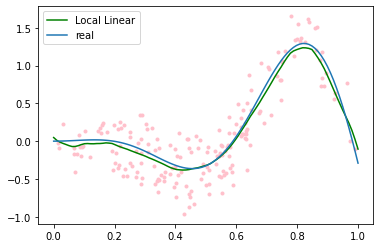

In [ ]:
Xlin=np.linspace(0,1,100)

Y_hat=np.array([LL(Xlin[i],X,Y, bandwidth=0.1) for i in range(100)])
plt.scatter(X,Y,marker='.',color='pink')
plt.plot(Xlin,Y_hat,color='green',label='Local Linear')
plt.plot(Xlin,non_pol_1(Xlin),label='real')
plt.legend()

plt.show()

**Weighted Nadaraya-Watson estimator**

In [ ]:
def lagrange_mult(x,X,kernel=epanechnikov,bandwidth=h):
  ##Newton method to find the root/lagrange multiplier for the underlying optimisation problem
  red2=X-x
  kweights=np.array([kernel(-z/bandwidth)/bandwidth for z in red2])
  s1=red2*kweights
  def func(lam):
    return np.mean(s1/(1+lam*s1))
  def func_prime(lam):
    return np.mean(-s1**2/(1+lam*s1)**2)
  ##Newton method
  lam=1
  for i in range(4): ###4 is too much, 3 is enough, 2 also gives enough precision but better runtime
    lam-=func(lam)/func_prime(lam)
  reduced_weights=1/X.size*1/(1+lam*s1)
  return lam,func(lam),reduced_weights,kweights

#print(lagrange_mult(1/2,X))

def WNW_weights(x,X,kernel=epanechnikov,bandwidth=h):
  l,f_l,reduced_weights,kweights=lagrange_mult(x,X,kernel=kernel,bandwidth=bandwidth)
  return reduced_weights*kweights

def WNW(x,X,Y,kernel=epanechnikov,bandwidth=h):
  W=WNW_weights(x,X,kernel=kernel,bandwidth=bandwidth)
  return weighted_average(Y,W)



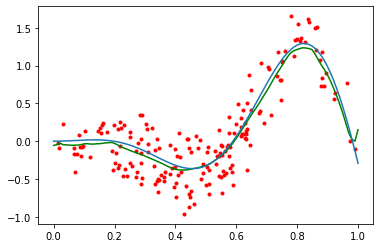

In [ ]:
Xlin=np.linspace(0,1,100)

Y_hat=np.array([WNW(Xlin[i],X,Y, bandwidth=0.1) for i in range(100)])
plt.scatter(X,Y,marker='.',color='red')
plt.plot(Xlin,Y_hat,color='green',label='Weighted Nadaraya-Watson')
plt.plot(Xlin,non_pol_1(Xlin),label='real')
plt.legend()
plt.show()

**Asymptotic study, fixed point**

In [ ]:
###Specific value for the asymptotic study of this estimator at x 
### x is in the middle, could be chosen anywhere not too close to the boundary at a given bandwidth

x=1/2

sigma2_x=var_noise(x)

g_x=pdf(x)

print(integrate.quad(pdf,0,1))

g_prime_x=pdf_prime(x)

m_x=non_pol_1(x) ###Regression target
m_prime_x=quadratic_prime(x)
m_seconde_x=quadratic_seconde(x)

mu2=integrate.quad(lambda u: x**2*epanechnikov(u),-1,1)[0]

nu0=integrate.quad(lambda u: epanechnikov(u)**2,-1,1)[0]

(1.0000000000000002, 1.1102230246251569e-14)


In [ ]:
def optimal_h(n,nu0=nu0,mu2=mu2,sigma2_x=sigma2_x,g_x=g_x,g_prime_x=g_prime_x,m_prime_x=m_prime_x,m_seconde_x=m_seconde_x,reg_type='WNW'):
  if reg_type=='WNW' or reg_type=='LL':
    return (nu0*sigma2_x/(mu2**2*g_x*m_seconde_x**2))**(0.2)/n**0.2
  else:
    return 0 ##TODO compute optimal_h at x for NW


def MSE_opt(n,nu0=nu0,mu2=mu2,sigma2_x=sigma2_x,g_x=g_x,g_prime_x=g_prime_x,m_prime_x=m_prime_x,m_seconde_x=m_seconde_x,reg_type='WNW'):
  if reg_type=='WNW' or reg_type=='LL':
    return 5/4*(nu0*sigma2_x*np.sqrt(mu2*np.abs(m_seconde_x))/(n*g_x))**(0.8)
  else:
    return 0 ##TODO compute optimal MSE at x for NW


def bias(h,m_seconde_x=m_seconde_x,mu2=mu2,reg_type='WNW'):###Be carefull, we need enough data points arround x...
  return 1/2*m_seconde_x*mu2*h**2

optimal_h(200),MSE_opt(100),bias(0.0748)


(0.22986290131657697, 0.006075885006333796, 0.0027975200000000004)

In [ ]:
### !! Cell takes a lot of time to run !!

data_points_number_schedule=[int(10**(5/16*i)) for i in range(12,20)] 

M=100 ###Monte Carlo Parameter for bias and MSE estimation 

X_training_list=[]
for n in data_points_number_schedule:
  temp=[]
  for i in range(M):
    temp.append(random_sample_normal(N=n)[0])
  X_training_list.append(temp)

print(X_training_list[0][0])

[0.54483433 0.30774644 0.61308401 ... 0.5611304  0.71957521 0.54636901]


In [ ]:
bias_optimal=[]
bias_estimate=[]
MSE_estimate=[]

for j in range(len(data_points_number_schedule)):
  n=data_points_number_schedule[j]
  h=optimal_h(n)
  bias_n,MSE_n=0,0
  for i in range(M):
    X=X_training_list[j][i]
    Y=quadratic(X)+noise(X)
    y_hat_x=WNW(x,X,Y,bandwidth=h)
    bias_n+=y_hat_x-quadratic(x)
    MSE_n+=(y_hat_x-quadratic(x))**2
  bias_n=bias_n/M
  MSE_n=MSE_n/M
  bias_estimate.append(bias_n)
  MSE_estimate.append(MSE_n)
  bias_optimal.append(bias(h))

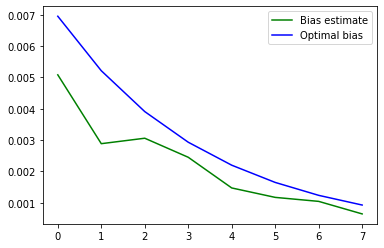

In [ ]:
#plt.plot(MSE_estimate,color='red', label='MSE estimate')
plt.plot(bias_estimate,color='green', label='Bias estimate')
plt.plot(bias_optimal,color='blue', label='Optimal bias')
plt.legend()
plt.show()

In [ ]:
###Log/Lin and Log/Log plot to check convergence rates ? -> already the case for the picture above but not explicitely visible on the axis

**Asymptotic study, boundary behavior**

In [ ]:
###30 sec to run 

X,pdf,pdf_prime=random_sample_normal(N=10000000)

print(X)

Y=non_pol_1(X)+noise(X)

c=1/2

[0.42927352 0.56388068 0.77052523 ... 0.3878572  0.83135765 0.35261589]


In [ ]:
x=0

sigma2_0=var_noise(x)

g_0=pdf(x)

g_prime_0=pdf_prime(x)

m_0=non_pol_1(x) ###Regression target
m_prime_0=quadratic_prime(x)
m_seconde_0=quadratic_seconde(x)

optimal_h(10000000,nu0=nu0,mu2=mu2,sigma2_x=sigma2_0,g_x=g_0,g_prime_x=g_prime_0,m_prime_x=m_prime_0,m_seconde_x=m_seconde_0,reg_type='WNW')

0.029181279570680205

We choose now a schedule for h where h higher than h optimal. That way the variance is reduced (at a cost on the bias...but we want to study how it evolves given h and whether Theorem 1 still holds...spoiler alert, it doesn't and we want here to quantify how much it fails)

In [ ]:
###We chose a schedule for h where h higher than h optimal. That way the variance is reduced (at a cost on the bias...but we want to study how it evolves given h )
h_schedule=[i/100 for i in range(5,20)]

bias_thm1=[bias(h,m_seconde_x=m_seconde_0) for h in h_schedule]

print(bias(optimal_h(1000000),m_seconde_x=m_seconde_0))

h_schedule


0.000875628262330927


[0.05,
 0.06,
 0.07,
 0.08,
 0.09,
 0.1,
 0.11,
 0.12,
 0.13,
 0.14,
 0.15,
 0.16,
 0.17,
 0.18,
 0.19]

In [ ]:
(np.sqrt(mu2)*nu0)**1.2

0.23580092567898683

In [ ]:
bias_ratio=[]
for h in h_schedule:
  y_hat=WNW(c*h,X,Y,bandwidth=h)
  bias_ratio.append((y_hat-non_pol_1(c*h))/bias(h,m_seconde_x=m_seconde_0))

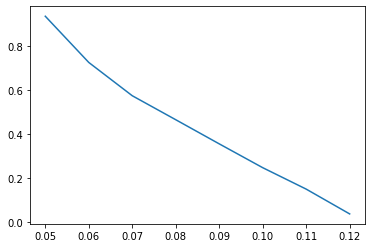

In [ ]:
### Is the formula for bias at the boundary the same as bias at the interior?
### We plot the ratio (the x-axis represents h)
plt.plot(h_schedule[:8],bias_ratio[:8])

As said in the presentation, Bias at the boundary is often lower than bias in the interior but variance is higher (we let you modify the cell just above the picture to compute MSE ratio)